# 05b — Temporal Validation

Validates the susceptibility map against **VIIRS 2023–2024** fire detections
(temporal holdout — independent of the MODIS 2001–2022 training data).

**Target:** >80% of actual fires fall in High + Very High risk zones.

**Outputs:**
- Zonal statistics table (printed)
- `outputs/validation_map.png` — susceptibility map with 2023–2024 fires overlaid
- `outputs/validation_stats.json` — machine-readable results for the paper

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

PROCESSED = Path('../data/processed')
RAW       = Path('../data/raw')
OUTPUTS   = Path('../outputs')

RISK_LABELS = {1: 'Low', 2: 'Moderate', 3: 'High', 4: 'Very High'}
RISK_COLORS = {1: '#2ecc71', 2: '#f1c40f', 3: '#e67e22', 4: '#c0392b'}

TIF_PATH = OUTPUTS / 'susceptibility.tif'
assert TIF_PATH.exists(), 'Run 05a_prediction_grid.ipynb first to generate susceptibility.tif'

print('Setup complete.')

Setup complete.


## 1 — Load VIIRS 2023–2024 fire detections

In [2]:
viirs_all = gpd.read_file(PROCESSED / 'firms_viirs.gpkg')
viirs_all['date'] = pd.to_datetime(viirs_all['date'])

print(f'VIIRS total detections: {len(viirs_all):,}')
print(f'Date range: {viirs_all["date"].min().date()} → {viirs_all["date"].max().date()}')

# Temporal holdout: 2023–2024 only (2022 overlaps with MODIS training period)
viirs = viirs_all[
    (viirs_all['date'] >= '2023-01-01') &
    (viirs_all['date'] <= '2024-12-31')
].copy().reset_index(drop=True)

print(f'\nVIIRS 2023–2024 detections: {len(viirs):,}')
print(f'Date range: {viirs["date"].min().date()} → {viirs["date"].max().date()}')

lons_fire = viirs.geometry.x.values
lats_fire = viirs.geometry.y.values

VIIRS total detections: 17,821
Date range: 2022-01-01 → 2026-03-28

VIIRS 2023–2024 detections: 9,401
Date range: 2023-01-02 → 2024-12-31


## 2 — Sample susceptibility raster at fire locations

In [3]:
coords = list(zip(lons_fire, lats_fire))

with rasterio.open(TIF_PATH) as src:
    print(f'Raster CRS: {src.crs}')
    print(f'Raster bounds: {src.bounds}')

    # Sample both bands at fire locations
    samples = list(src.sample(coords))
    proba_at_fire = np.array([s[0] for s in samples], dtype=float)   # Band 1: probability
    class_at_fire = np.array([s[1] for s in samples], dtype=float)   # Band 2: risk class

viirs['susceptibility'] = proba_at_fire
viirs['risk_class']     = class_at_fire

# Fires that fell outside the raster (masked / NaN)
n_outside = np.isnan(proba_at_fire).sum()
print(f'\nFire points outside raster extent: {n_outside} ({100*n_outside/len(viirs):.1f}%)')

# Drop points outside raster
viirs = viirs[~np.isnan(viirs['susceptibility'])].reset_index(drop=True)
print(f'Remaining fire points for validation: {len(viirs):,}')

Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=-65.7782592779999, bottom=-34.99873351899993, right=-61.77767181399997, top=-29.503320692999978)



Fire points outside raster extent: 24 (0.3%)
Remaining fire points for validation: 9,377


## 3 — Zonal statistics

In [4]:
total_fires = len(viirs)

print('=' * 62)
print('TEMPORAL VALIDATION — VIIRS 2023–2024')
print('=' * 62)
print(f'Total fires validated: {total_fires:,}\n')

rows = []
for cls in [1, 2, 3, 4]:
    count = (viirs['risk_class'] == cls).sum()
    pct   = 100 * count / total_fires
    rows.append({'Risk Zone': RISK_LABELS[cls], 'Fires': count, 'Pct (%)': round(pct, 2)})
    print(f'  {RISK_LABELS[cls]:10s}: {count:6,}  ({pct:5.1f}%)')

stats_df = pd.DataFrame(rows)

# Target metric
n_high    = (viirs['risk_class'] >= 3).sum()
pct_high  = 100 * n_high / total_fires
TARGET    = 80.0
passed    = pct_high >= TARGET

print(f'\n{"─" * 62}')
print(f'High + Very High: {n_high:,} fires = {pct_high:.1f}%')
print(f'Target           : ≥{TARGET:.0f}%')
print(f'Result           : {"✓ PASS" if passed else "✗ FAIL"}')
print('=' * 62)

stats_df

TEMPORAL VALIDATION — VIIRS 2023–2024
Total fires validated: 9,377

  Low       :     44  (  0.5%)
  Moderate  :    973  ( 10.4%)
  High      :  2,287  ( 24.4%)
  Very High :  6,073  ( 64.8%)

──────────────────────────────────────────────────────────────
High + Very High: 8,360 fires = 89.2%
Target           : ≥80%
Result           : ✓ PASS


,Risk Zone,Fires,Pct (%)
0,Low,44,0.47
1,Moderate,973,10.38
2,High,2287,24.39
3,Very High,6073,64.76


## 4 — Susceptibility distribution at fire locations

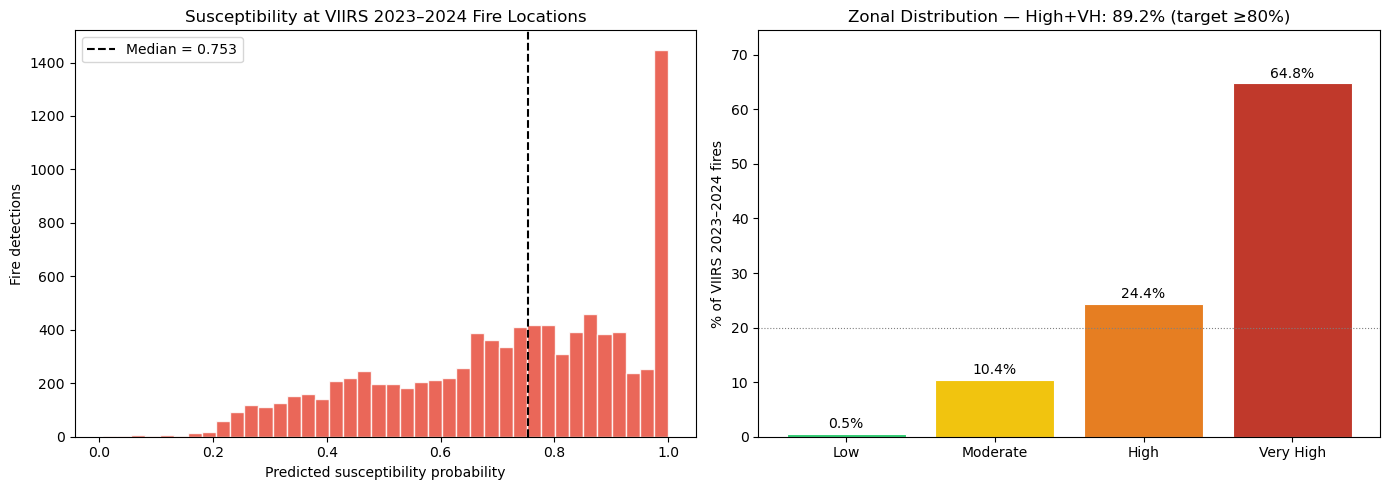

Saved → ../outputs/validation_zonal_stats.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of susceptibility probability at fire locations
ax = axes[0]
ax.hist(viirs['susceptibility'], bins=40, color='#e74c3c', edgecolor='white', alpha=0.85)
ax.axvline(viirs['susceptibility'].median(), color='black', linestyle='--',
           label=f'Median = {viirs["susceptibility"].median():.3f}')
ax.set_xlabel('Predicted susceptibility probability')
ax.set_ylabel('Fire detections')
ax.set_title('Susceptibility at VIIRS 2023–2024 Fire Locations')
ax.legend()

# Right: bar chart of % fires per risk zone
ax = axes[1]
colors = [RISK_COLORS[i] for i in [1, 2, 3, 4]]
labels = [r['Risk Zone'] for r in rows]
pcts   = [r['Pct (%)'] for r in rows]
bars   = ax.bar(labels, pcts, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(20, color='gray', linestyle=':', linewidth=0.8, label='Equal share (25%)')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('% of VIIRS 2023–2024 fires')
ax.set_title(f'Zonal Distribution — High+VH: {pct_high:.1f}% (target ≥{TARGET:.0f}%)')
ax.set_ylim(0, max(pcts) * 1.15)

plt.tight_layout()
plt.savefig(OUTPUTS / 'validation_zonal_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUTS}/validation_zonal_stats.png')

## 5 — Validation map (susceptibility + 2023–2024 fires overlaid)

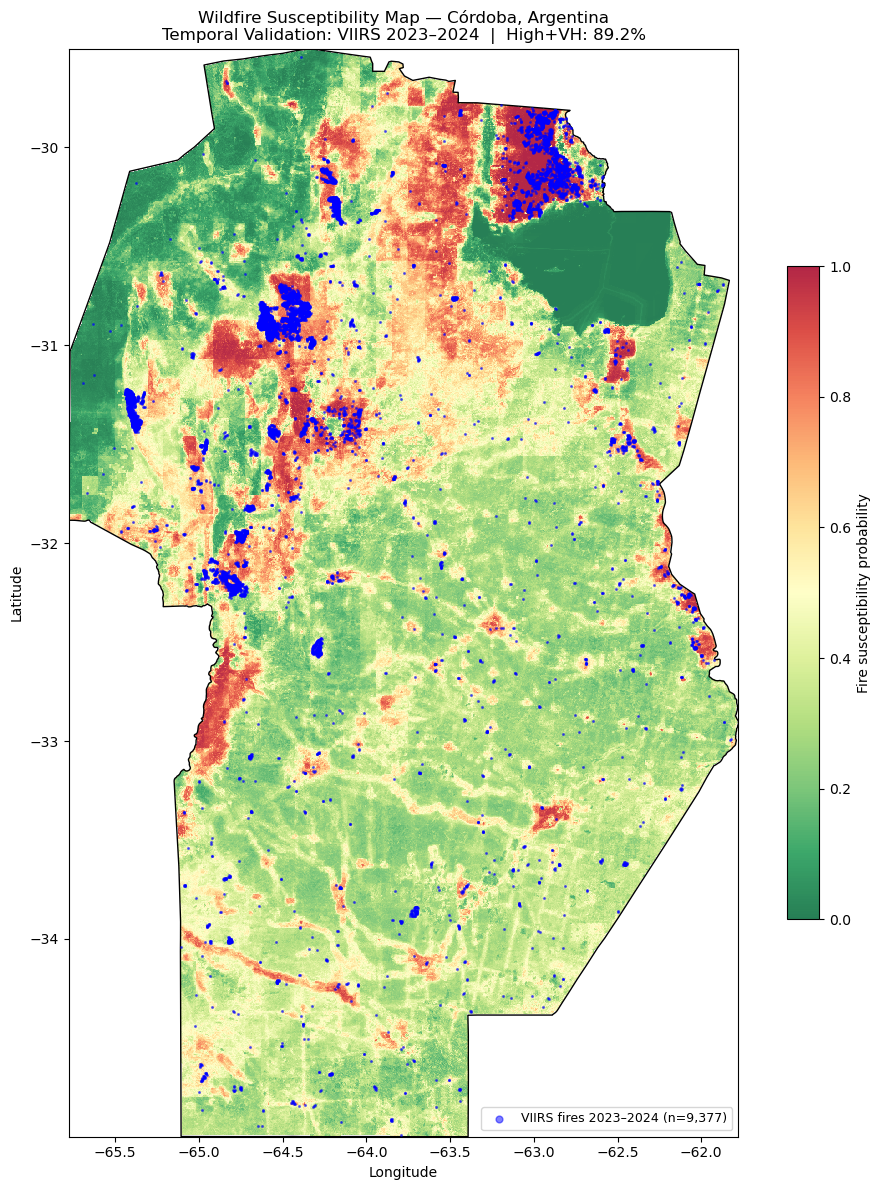

Validation map saved → ../outputs/validation_map.png


In [6]:
# Load boundary
boundary = gpd.read_file(RAW / 'cordoba_boundary.shp').to_crs('EPSG:4326')

# Read susceptibility raster for background
with rasterio.open(TIF_PATH) as src:
    prob_band = src.read(1)  # probability band
    bounds    = src.bounds

# Mask nodata
prob_display = np.where(np.isnan(prob_band), np.nan, prob_band)

fig, ax = plt.subplots(figsize=(10, 12))

# Background: susceptibility raster
im = ax.imshow(
    prob_display,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    aspect='equal',
    origin='upper',
    alpha=0.85,
    interpolation='nearest',
)
plt.colorbar(im, ax=ax, shrink=0.6, label='Fire susceptibility probability')

# Province boundary
boundary.boundary.plot(ax=ax, color='black', linewidth=1.0, zorder=3)

# VIIRS 2023–2024 fires (small dots, semi-transparent)
ax.scatter(
    viirs.geometry.x, viirs.geometry.y,
    s=1.5, c='blue', alpha=0.5, zorder=4, label=f'VIIRS fires 2023–2024 (n={len(viirs):,})'
)

ax.set_title(
    f'Wildfire Susceptibility Map — Córdoba, Argentina\n'
    f'Temporal Validation: VIIRS 2023–2024  |  High+VH: {pct_high:.1f}%',
    fontsize=12
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower right', fontsize=9, markerscale=4)

plt.tight_layout()
plt.savefig(OUTPUTS / 'validation_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Validation map saved → {OUTPUTS}/validation_map.png')

## 6 — Save validation stats (for paper & dashboard)

In [7]:
validation_stats = {
    'n_fires_total'        : int(total_fires),
    'n_fires_high_vh'      : int(n_high),
    'pct_high_vh'          : round(float(pct_high), 2),
    'target_pct'           : TARGET,
    'passed'               : bool(passed),
    'median_susceptibility': round(float(viirs['susceptibility'].median()), 4),
    'mean_susceptibility'  : round(float(viirs['susceptibility'].mean()), 4),
    'validation_period'    : '2023-01-01 to 2024-12-31',
    'sensor'               : 'VIIRS VNP14IMG',
    'zonal_stats'          : [
        {
            'risk_class': int(r),
            'label'     : RISK_LABELS[r],
            'n_fires'   : int((viirs['risk_class'] == r).sum()),
            'pct'       : round(100 * float((viirs['risk_class'] == r).sum()) / total_fires, 2),
        }
        for r in [1, 2, 3, 4]
    ],
}

out_json = OUTPUTS / 'validation_stats.json'
with open(out_json, 'w') as f:
    json.dump(validation_stats, f, indent=2)

print(f'Validation stats saved → {out_json}')
print()
print('=' * 50)
print('Phase 5B — Validation Summary')
print('=' * 50)
print(f'VIIRS 2023–2024 fires : {total_fires:,}')
print(f'High + Very High      : {pct_high:.1f}%  (target ≥{TARGET:.0f}%)')
print(f'Verdict               : {"PASS" if passed else "FAIL"}')
print('=' * 50)
print('Phase 5 complete. Ready for Phase 6 (dashboard).')

Validation stats saved → ../outputs/validation_stats.json

Phase 5B — Validation Summary
VIIRS 2023–2024 fires : 9,377
High + Very High      : 89.2%  (target ≥80%)
Verdict               : PASS
Phase 5 complete. Ready for Phase 6 (dashboard).
